In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "mrpc"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence1', 'sentence2', 'label', 'idx'],
    num_rows: 3668
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1725
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence1': 'Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .',
 'sentence2': 'Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .',
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence1'], raw_train_dataset[5]['sentence2']

('Revenue in the first quarter of the year dropped 15 percent from the same period a year earlier .',
 "With the scandal hanging over Stewart 's company , revenue the first quarter of the year dropped 15 percent from the same period a year earlier .")

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence1': Value('string'),
 'sentence2': Value('string'),
 'label': ClassLabel(names=['not_equivalent', 'equivalent']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence1"], example["sentence2"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 100]),
 'token_type_ids': torch.Size([32, 100]),
 'attention_mask': torch.Size([32, 100])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(1.2996, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda', index=1)

### Load Trained Weights

In [26]:
load_path = '../glue_fine_tune/weights/'
best_weight = torch.load(load_path + f'bert-{task_name}.pt', map_location=device)
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [27]:
from train_eval_func import eval_loop

In [28]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'accuracy': 0.8676470588235294, 'f1': 0.9093959731543624}

### Load Trained Weights for Model with 8 Layers

In [29]:
import os
from merge_helper import merge_bert_layers, LayerMergeTracker, apply_layer_tracking_to_model
from train_eval_func import train, get_primary_metric, set_lr_scheduler, get_recovery_epoch
from torch.optim import AdamW

In [30]:
model_8 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-8-{task_name}.pt', map_location=device)

In [32]:
model_8 = apply_layer_tracking_to_model(model_8, graft_state['layer_track'])

In [33]:
len(model_8.bert.encoder.layer)

8

In [34]:
model_8.to(device)
device

device(type='cuda', index=1)

In [35]:
model_8.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [36]:
eval_loop(model_8, val_dataloader, task_name, device)[0]

{'accuracy': 0.8578431372549019, 'f1': 0.8996539792387543}

### Load Trained Weights for Model with 7 Layers

In [37]:
model_7 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-7-{task_name}.pt', map_location=device)

In [39]:
model_7 = apply_layer_tracking_to_model(model_7, graft_state['layer_track'])

In [40]:
len(model_7.bert.encoder.layer)

7

In [41]:
model_7.to(device)
device

device(type='cuda', index=1)

In [42]:
model_7.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [43]:
eval_loop(model_7, val_dataloader, task_name, device)[0]

{'accuracy': 0.8700980392156863, 'f1': 0.9084628670120898}

### Load Trained Weights for Model with 6 Layers

In [44]:
model_6 = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [45]:
load_graft_path = '../similar_layer_merge/weights/'
graft_state = torch.load(load_graft_path + f'layer-6-{task_name}.pt', map_location=device)

In [46]:
model_6 = apply_layer_tracking_to_model(model_6, graft_state['layer_track'])

In [47]:
len(model_6.bert.encoder.layer)

6

In [48]:
model_6.to(device)
device

device(type='cuda', index=1)

In [49]:
model_6.load_state_dict(graft_state['model_state_dict'])

<All keys matched successfully>

In [50]:
eval_loop(model_6, val_dataloader, task_name, device)[0]

{'accuracy': 0.8480392156862745, 'f1': 0.8938356164383562}

In [51]:
print(model.bert.encoder.layer[0].state_dict().keys())

odict_keys(['attention.self.query.weight', 'attention.self.query.bias', 'attention.self.key.weight', 'attention.self.key.bias', 'attention.self.value.weight', 'attention.self.value.bias', 'attention.output.dense.weight', 'attention.output.dense.bias', 'attention.output.LayerNorm.weight', 'attention.output.LayerNorm.bias', 'intermediate.dense.weight', 'intermediate.dense.bias', 'output.dense.weight', 'output.dense.bias', 'output.LayerNorm.weight', 'output.LayerNorm.bias'])


# 5. Pruning Sweep — Depth Model vs Width Model

We compare how **two structurally different fine-tuned BERT variants** respond to
unstructured L1 weight pruning at five sparsity levels: **10%, 20%, 30%, 40%, 50%**.

| Model | Structure |
|---|---|
| `model` | Standard BERT-base (12 layers, depth) |
| `graft_model` | Width-merged BERT (6 layers, 2× internal width) |

### GPU-efficient strategy
- Both models stay on GPU throughout — no `.to(device)` inside the loop
- Original dense weights are cached **once** as CPU tensors
- Between pruning levels, weights are restored via a CPU→GPU `load_state_dict` copy
- Stale masks are stripped with `remove_all_masks()` before each new level


In [52]:
from prune_helper import remove_all_masks, apply_pruning, global_sparsity, make_permanent, compare_pruning_robustness, print_pruning_results, plot_pruning_comparison

In [53]:
# Cache both models' dense weights on CPU — cheap to store, cheap to restore
depth_state_cpu = {k: v.cpu().clone() for k, v in model.state_dict().items()}
width_state_8_cpu = {k: v.cpu().clone() for k, v in model_8.state_dict().items()}
width_state_7_cpu = {k: v.cpu().clone() for k, v in model_7.state_dict().items()}
width_state_6_cpu = {k: v.cpu().clone() for k, v in model_6.state_dict().items()}

print(f'Depth model: {len(depth_state_cpu)} tensors cached on CPU')
print(f'Width model (8 layers): {len(width_state_8_cpu)} tensors cached on CPU')
print(f'Width model (7 layers): {len(width_state_7_cpu)} tensors cached on CPU')
print(f'Width model (6 layers): {len(width_state_6_cpu)} tensors cached on CPU')
print(f'GPU device : {device}')


Depth model: 201 tensors cached on CPU
Width model (8 layers): 137 tensors cached on CPU
Width model (7 layers): 121 tensors cached on CPU
Width model (6 layers): 105 tensors cached on CPU
GPU device : cuda:1


In [54]:
model.eval()
model_8.eval()
model_7.eval()
model_6.eval()

baseline_depth, _ = eval_loop(model, val_dataloader, task_name, device)
baseline_width_8, _ = eval_loop(model_8, val_dataloader, task_name, device)
baseline_width_7, _ = eval_loop(model_7, val_dataloader, task_name, device)
baseline_width_6, _ = eval_loop(model_6, val_dataloader, task_name, device)

print(f'Baseline — Depth model (12-layer)')
for metric_name, value in baseline_depth.items():
    print(f"- {metric_name}: {value:.4f}")

print(f'Baseline — Width model (8-layer)')
for metric_name, value in baseline_width_8.items():
    print(f"- {metric_name}: {value:.4f}")

print(f'Baseline — Width model (7-layer)')
for metric_name, value in baseline_width_7.items():
    print(f"- {metric_name}: {value:.4f}")

print(f'Baseline — Width model (6-layer)')
for metric_name, value in baseline_width_6.items():
    print(f"- {metric_name}: {value:.4f}")


Baseline — Depth model (12-layer)
- accuracy: 0.8676
- f1: 0.9094
Baseline — Width model (8-layer)
- accuracy: 0.8578
- f1: 0.8997
Baseline — Width model (7-layer)
- accuracy: 0.8701
- f1: 0.9085
Baseline — Width model (6-layer)
- accuracy: 0.8480
- f1: 0.8938


In [55]:
# Pass models with baselines
models = {
    '12-layer': (model, baseline_depth),
    '8-layer': (model_8, baseline_width_8),
    '7-layer': (model_7, baseline_width_7),
    '6-layer': (model_6, baseline_width_6),
}

In [56]:
results = compare_pruning_robustness(
    models_dict=models,
    eval_dataloader=val_dataloader,  # or eval_dataloader
    task_name=task_name,
    device=device,
    pruning_levels=[0.10, 0.20, 0.30, 0.40, 0.50],
    save_checkpoints=False
)

Caching original model states...
  ✓ Cached 12-layer
  ✓ Cached 8-layer
  ✓ Cached 7-layer
  ✓ Cached 6-layer

BASELINE METRICS

12-layer:
    accuracy: 0.8676
  ★ f1: 0.9094

8-layer:
    accuracy: 0.8578
  ★ f1: 0.8997

7-layer:
    accuracy: 0.8701
  ★ f1: 0.9085

6-layer:
    accuracy: 0.8480
  ★ f1: 0.8938

PRUNING SWEEP

════════════════════════════════════════════════════════════
  Pruning Level: 10%
════════════════════════════════════════════════════════════

  [12-layer]
    F1: 0.9097  (Δ -0.0003)
    Sparsity: 10.00%

  [8-layer]
    F1: 0.8966  (Δ +0.0031)
    Sparsity: 10.00%

  [7-layer]
    F1: 0.9053  (Δ +0.0031)
    Sparsity: 10.00%

  [6-layer]
    F1: 0.8961  (Δ -0.0022)
    Sparsity: 10.00%

════════════════════════════════════════════════════════════
  Pruning Level: 20%
════════════════════════════════════════════════════════════

  [12-layer]
    F1: 0.9079  (Δ +0.0015)
    Sparsity: 20.00%

  [8-layer]
    F1: 0.8974  (Δ +0.0023)
    Sparsity: 20.00%

  [7-laye

In [57]:
# Print results
print_pruning_results(models, results)


PRUNING RESULTS SUMMARY

12-layer:
 Pruning %    Sparsity %            F1      Accuracy  
--------------------------------------------------------------------------------
  0 (base)          0.00        0.9094        0.8676  
        10         10.00        0.9097        0.8676  
        20         20.00        0.9079        0.8652  
        30         30.00        0.9044        0.8627  
        40         40.00        0.9050        0.8652  
        50         50.00        0.8561        0.8113  

8-layer:
 Pruning %    Sparsity %            F1      Accuracy  
--------------------------------------------------------------------------------
  0 (base)          0.00        0.8997        0.8578  
        10         10.00        0.8966        0.8529  
        20         20.00        0.8974        0.8554  
        30         30.00        0.8980        0.8603  
        40         40.00        0.8861        0.8456  
        50         50.00        0.8016        0.7598  

7-layer:
 Pruning %  

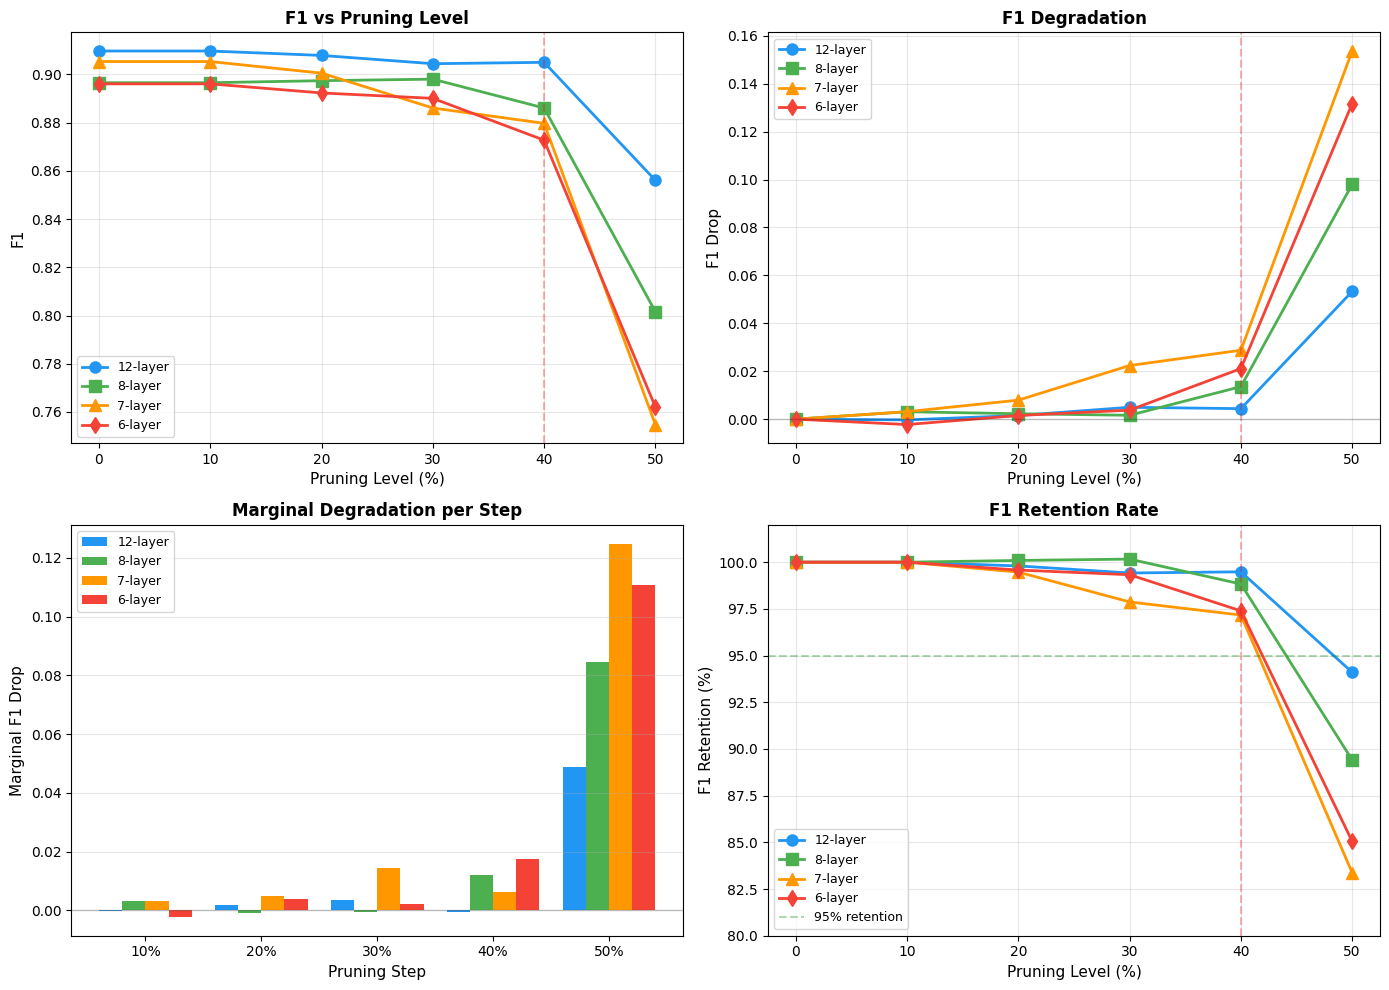

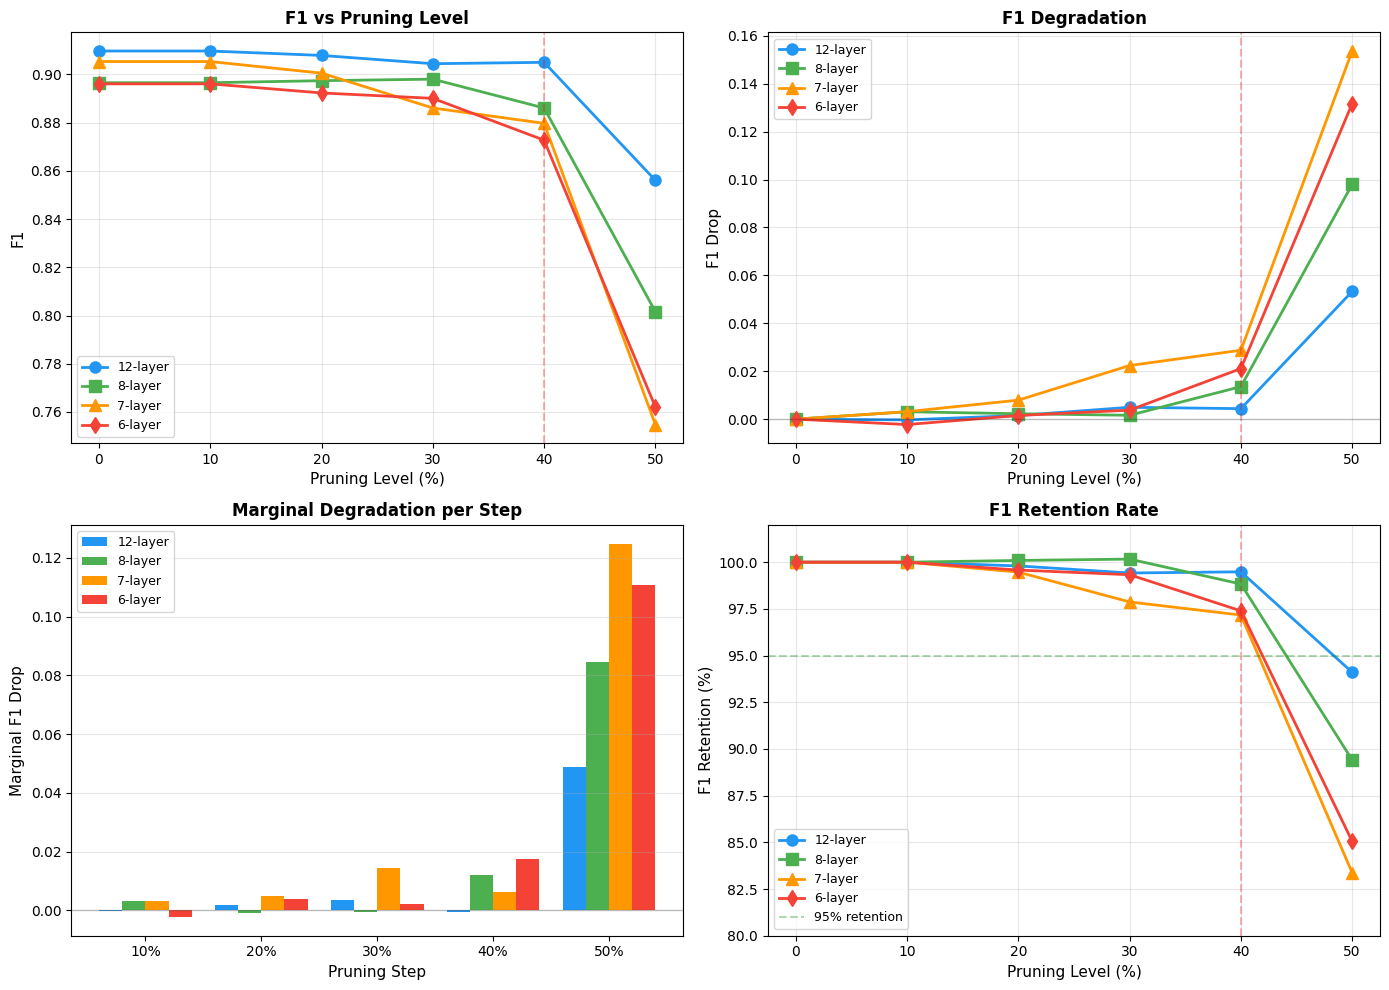

In [58]:
plot_pruning_comparison(results_dict=results)

# 6. Global Pruning — Attention vs FFN Separately

**Local pruning** (Section 5) removes the lowest X% of weights *within each layer*,
treating every layer equally regardless of how important its weights are.

**Global pruning** ranks weights *across all layers of the same type* and removes
the globally weakest ones — so some layers get pruned more than others based on
their actual weight magnitudes. This is generally smarter.

We split the model into **two global pools**:

| Pool | Layers included |
|---|---|
| **Attention** | `query`, `key`, `value`, `attention.output.dense` across all encoder layers |
| **FFN** | `intermediate.dense`, `output.dense` across all encoder layers |

This lets you control attention sparsity and FFN sparsity independently —
e.g. prune FFN aggressively (it's 2/3 of BERT's parameters) while being
gentler on attention.


In [59]:
from prune_helper import get_global_pruning_params, apply_global_pruning, pool_sparsity, remove_global_masks, remove_all_global_masks, describe_pools, print_per_layer_sparsity, compare_global_pruning_robustness

## Inspect Pool Sizes

In [62]:
describe_pools(model,  'Depth model (12-layer standard BERT)')
describe_pools(model_8, 'Width model (8-layer merged BERT)')
describe_pools(model_7, 'Width model (7-layer merged BERT)')
describe_pools(model_6, 'Width model (6-layer merged BERT)')


── Depth model (12-layer standard BERT) ──
  Attention pool :  48 Linear layers  |    28,311,552 params  (33.3%)
  FFN pool       :  24 Linear layers  |    56,623,104 params  (66.7%)
  Total          :      72 Linear layers  |    84,934,656 params

── Width model (8-layer merged BERT) ──
  Attention pool :  32 Linear layers  |    28,311,552 params  (33.3%)
  FFN pool       :  16 Linear layers  |    56,623,104 params  (66.7%)
  Total          :      48 Linear layers  |    84,934,656 params

── Width model (7-layer merged BERT) ──
  Attention pool :  28 Linear layers  |    28,311,552 params  (33.3%)
  FFN pool       :  14 Linear layers  |    56,623,104 params  (66.7%)
  Total          :      42 Linear layers  |    84,934,656 params

── Width model (6-layer merged BERT) ──
  Attention pool :  24 Linear layers  |    28,311,552 params  (33.3%)
  FFN pool       :  12 Linear layers  |    56,623,104 params  (66.7%)
  Total          :      36 Linear layers  |    84,934,656 params


## Global Pruning Sweep¶

In [63]:
results = compare_global_pruning_robustness(
    models_dict=models,
    eval_dataloader=val_dataloader,
    task_name=task_name,
    device=device,
    save_checkpoints=False
)

Caching original model states...
  ✓ Cached 12-layer
  ✓ Cached 8-layer
  ✓ Cached 7-layer
  ✓ Cached 6-layer

BASELINE METRICS

12-layer:
    accuracy: 0.8676
  ★ f1: 0.9094

8-layer:
    accuracy: 0.8578
  ★ f1: 0.8997

7-layer:
    accuracy: 0.8701
  ★ f1: 0.9085

6-layer:
    accuracy: 0.8480
  ★ f1: 0.8938

GLOBAL PRUNING SWEEP (Attention vs FFN)

══════════════════════════════════════════════════════════════
  Uniform 10%
══════════════════════════════════════════════════════════════

  [12-layer]
    F1: 0.8561  (Δ +0.0533)
    Attn sparsity: 50.00%
    FFN sparsity:  50.00%
    Total sparsity: 50.00%

  [8-layer]
    F1: 0.8016  (Δ +0.0980)
    Attn sparsity: 50.00%
    FFN sparsity:  50.00%
    Total sparsity: 50.00%

  [7-layer]
    F1: 0.7548  (Δ +0.1537)
    Attn sparsity: 50.00%
    FFN sparsity:  50.00%
    Total sparsity: 50.00%

  [6-layer]
    F1: 0.7621  (Δ +0.1317)
    Attn sparsity: 50.00%
    FFN sparsity:  50.00%
    Total sparsity: 50.00%

═══════════════════════

In [67]:
results = compare_global_pruning_robustness(
    models_dict=models,
    eval_dataloader=val_dataloader,
    task_name=task_name,
    device=device,
    save_checkpoints=False,
    pruning_configs=[
        (0, 0.2),  # FFN-only 20%
        (0, 0.3),  # FFN-only 30%
        (0, 0.4),  # FFN-only 40%
        (0, 0.5),  # FFN-only 50%
    ]
)

Caching original model states...
  ✓ Cached 12-layer
  ✓ Cached 8-layer
  ✓ Cached 7-layer
  ✓ Cached 6-layer

BASELINE METRICS

12-layer:
    accuracy: 0.8676
  ★ f1: 0.9094

8-layer:
    accuracy: 0.8578
  ★ f1: 0.8997

7-layer:
    accuracy: 0.8701
  ★ f1: 0.9085

6-layer:
    accuracy: 0.8480
  ★ f1: 0.8938

GLOBAL PRUNING SWEEP (Attention vs FFN)

══════════════════════════════════════════════════════════════
  FFN-only 20%
══════════════════════════════════════════════════════════════

  [12-layer]
    F1: 0.8561  (Δ +0.0533)
    FFN sparsity:  50.00%

  [8-layer]
    F1: 0.8016  (Δ +0.0980)
    FFN sparsity:  50.00%

  [7-layer]
    F1: 0.7548  (Δ +0.1537)
    FFN sparsity:  50.00%

  [6-layer]
    F1: 0.7621  (Δ +0.1317)
    FFN sparsity:  50.00%

══════════════════════════════════════════════════════════════
  FFN-only 30%
══════════════════════════════════════════════════════════════

  [12-layer]
    F1: 0.8561  (Δ +0.0533)
    FFN sparsity:  50.00%

  [8-layer]
    F1: 0.80

In [68]:
results = compare_global_pruning_robustness(
    models_dict=models,
    eval_dataloader=val_dataloader,
    task_name=task_name,
    device=device,
    save_checkpoints=False,
    pruning_configs=[
        (0.2, 0),  # Attn-only 20%
        (0.3, 0),  # Attn-only 30%
        (0.4, 0),  # Attn-only 40%
        (0.5, 0),  # Attn-only 50%
    ]
)

Caching original model states...
  ✓ Cached 12-layer
  ✓ Cached 8-layer
  ✓ Cached 7-layer
  ✓ Cached 6-layer

BASELINE METRICS

12-layer:
    accuracy: 0.8676
  ★ f1: 0.9094

8-layer:
    accuracy: 0.8578
  ★ f1: 0.8997

7-layer:
    accuracy: 0.8701
  ★ f1: 0.9085

6-layer:
    accuracy: 0.8480
  ★ f1: 0.8938

GLOBAL PRUNING SWEEP (Attention vs FFN)

══════════════════════════════════════════════════════════════
  Attn-only 20%
══════════════════════════════════════════════════════════════

  [12-layer]
    F1: 0.8561  (Δ +0.0533)
    Attn sparsity: 50.00%

  [8-layer]
    F1: 0.8016  (Δ +0.0980)
    Attn sparsity: 50.00%

  [7-layer]
    F1: 0.7548  (Δ +0.1537)
    Attn sparsity: 50.00%

  [6-layer]
    F1: 0.7621  (Δ +0.1317)
    Attn sparsity: 50.00%

══════════════════════════════════════════════════════════════
  Attn-only 30%
══════════════════════════════════════════════════════════════

  [12-layer]
    F1: 0.8561  (Δ +0.0533)
    Attn sparsity: 50.00%

  [8-layer]
    F1: 0.